In [9]:
import pandas as pd

df = pd.read_csv("airline_passengers.csv")
df.head()

,"Month""",Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [10]:
df.columns = df.columns.str.replace('"', '').str.strip()
print(df.columns)

Index(['Month', 'Passengers'], dtype='object')


In [11]:
df['Month'] = pd.to_datetime(df['Month'])

In [12]:
df = df.sort_values('Month')

In [13]:
df = df.sort_values('Month')

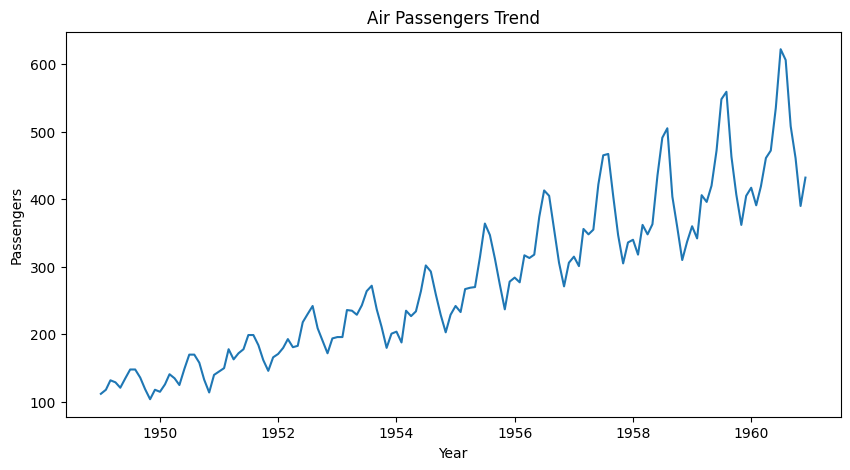

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Passengers'])
plt.title("Air Passengers Trend")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

In [15]:
df = df.rename(columns={'Month': 'ds', 'Passengers': 'y'})
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [16]:
!pip install prophet

In [17]:
from prophet import Prophet

model = Prophet()
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [18]:
future = model.make_future_dataframe(periods=24, freq='M')
future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
163,1962-07-31
164,1962-08-31
165,1962-09-30
166,1962-10-31
167,1962-11-30


In [19]:
forecast = model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
163,1962-07-31,612.801493,584.120984,641.756021
164,1962-08-31,567.637866,541.982806,596.185616
165,1962-09-30,529.891741,501.367614,558.620412
166,1962-10-31,501.171369,469.881235,528.243930
167,1962-11-30,530.711388,502.832165,558.608692


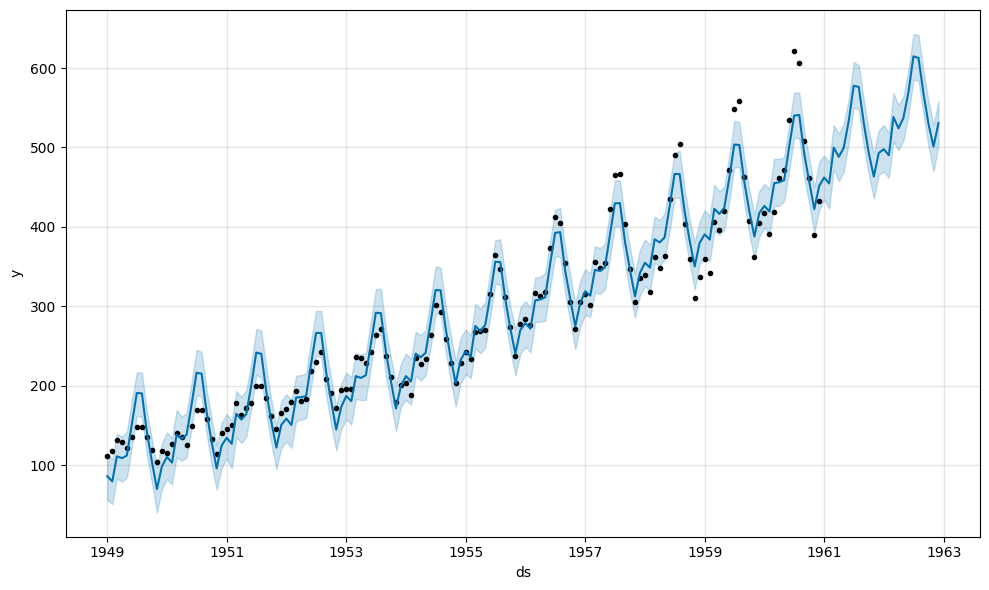

In [20]:
fig = model.plot(forecast)
plt.show()

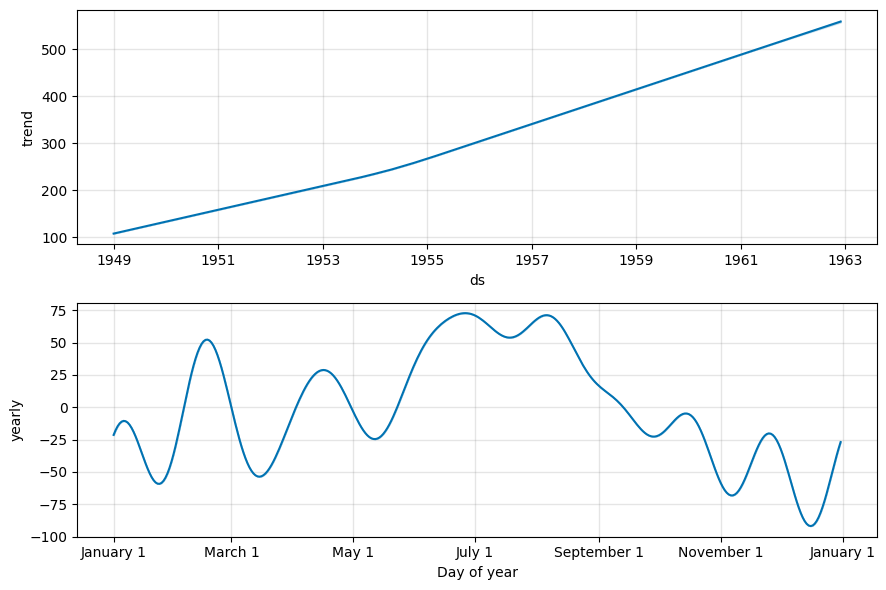

In [21]:
fig2 = model.plot_components(forecast)
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# split into train/test
train = df[:-12]
test = df[-12:]

model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

pred = forecast[-12:]['yhat']

mae = mean_absolute_error(test['y'], pred)
rmse = np.sqrt(mean_squared_error(test['y'], pred))

print("MAE:", mae)
print("RMSE:", rmse)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE: 33.980559509262676
RMSE: 41.50981271869941


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
